<a href="https://colab.research.google.com/github/LadonV/Data-Viz/blob/main/Exam_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exam 2

## Ladon Vance CPSMA 4313

In [16]:
import requests
import pandas as pa
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

In [17]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

r = requests.get('https://en.wikipedia.org/wiki/List_of_mountains_by_elevation', headers=headers)
html_contents = r.text
html_soup = BeautifulSoup(html_contents,"lxml")

In [18]:
len(html_soup.find_all('table'))

9

In [19]:
tables = html_soup.find_all('table',class_="wikitable")
tables[0].find_all('a')

[<a href="/wiki/Mount_Everest" title="Mount Everest">Mount Everest</a>,
 <a href="/wiki/Geography_of_Nepal" title="Geography of Nepal">Nepal</a>,
 <a href="/wiki/K2" title="K2">K2</a>,
 <a href="/wiki/Kangchenjunga" title="Kangchenjunga">Kangchenjunga</a>,
 <a href="/wiki/Lhotse" title="Lhotse">Lhotse</a>,
 <a href="/wiki/Makalu" title="Makalu">Makalu</a>,
 <a href="/wiki/Cho_Oyu" title="Cho Oyu">Cho Oyu</a>,
 <a href="/wiki/Dhaulagiri" title="Dhaulagiri">Dhaulagiri</a>,
 <a href="/wiki/Manaslu" title="Manaslu">Manaslu</a>,
 <a href="/wiki/Nanga_Parbat" title="Nanga Parbat">Nanga Parbat</a>,
 <a href="/wiki/Annapurna" title="Annapurna">Annapurna</a>,
 <a href="/wiki/Gasherbrum_I" title="Gasherbrum I">Gasherbrum I</a>,
 <a href="/wiki/Broad_Peak" title="Broad Peak">Broad Peak</a>,
 <a href="/wiki/Gasherbrum_II" title="Gasherbrum II">Gasherbrum II</a>,
 <a href="/wiki/Shishapangma" title="Shishapangma">Shishapangma</a>]

In [20]:
df = pa.read_html(str(tables))[0]
df

/tmp/ipykernel_5384/1012347685.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pa.read_html(str(tables))[0]


,Mountain,Metres,Feet,Range,Location and notes
0,Mount Everest,8848,29029,Himalayas,Nepal/China
1,K2,8611,28251,Karakoram,Pakistan/China
2,Kangchenjunga,8586,28169,Himalayas,Nepal/India
3,Lhotse,8516,27940,Himalayas,Nepal – Climbers ascend Lhotse Face in climbin...
4,Makalu,8485,27838,Himalayas,Nepal
5,Cho Oyu,8188,26864,Himalayas,"Nepal – Considered ""easiest"" eight-thousander"
6,Dhaulagiri,8167,26795,Himalayas,Nepal – Presumed world's highest from 1808-1838
7,Manaslu,8163,26781,Himalayas,Nepal
8,Nanga Parbat,8126,26660,Himalayas,Pakistan
9,Annapurna,8091,26545,Himalayas,Nepal – First eight-thousander to be climbed (...


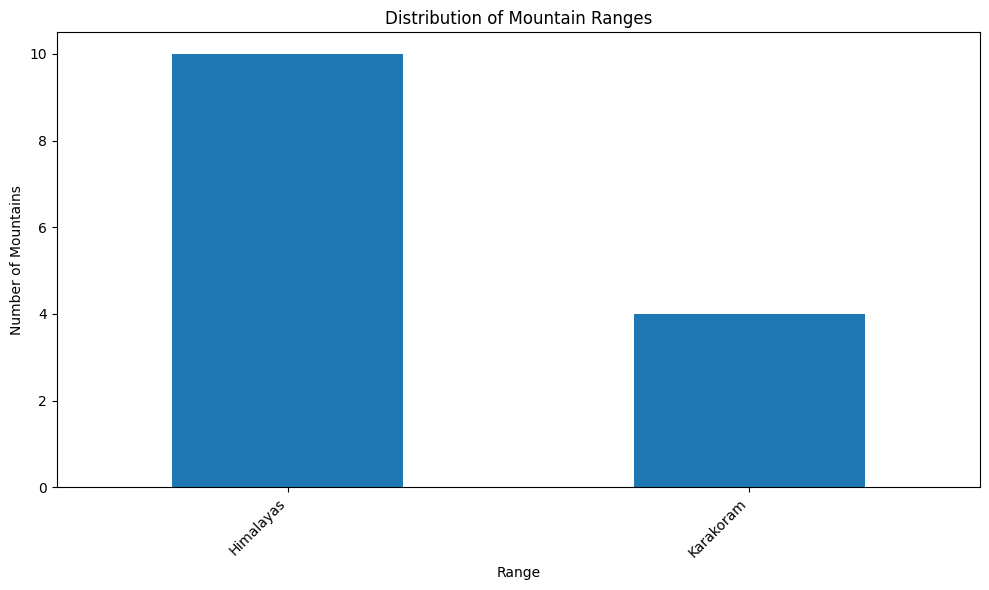

In [21]:
range_counts = df['Range'].value_counts()

plt.figure(figsize=(10, 6))
range_counts.plot(kind='bar')
plt.title('Distribution of Mountain Ranges')
plt.xlabel('Range')
plt.ylabel('Number of Mountains')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Asked Gemini to "create a barchart of ranges" didn't need to change anything, gave me to bars of the two mountain ranges. Himalayas had 10 mountains above 8000 meters while Karakoram has 4.

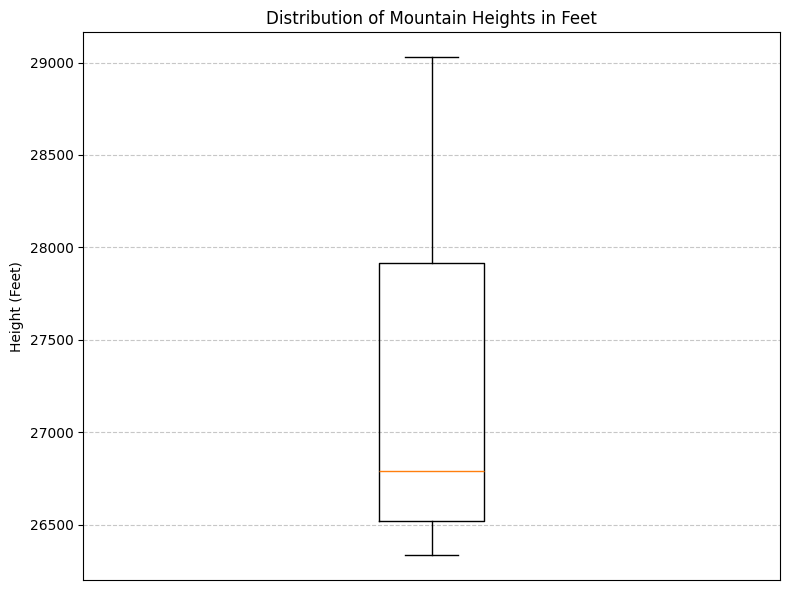

In [22]:
plt.figure(figsize=(8, 6))
plt.boxplot(df['Feet'])
plt.title('Distribution of Mountain Heights in Feet')
plt.ylabel('Height (Feet)')
plt.xticks([]) # Hide x-axis ticks as it's a single box plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Asked gemini "create a box-plot of the height in Feet. The mean is between 26500 and 27000 while the middle 50% is from around 26500 and 28000.

In [23]:
height_stats = df['Feet'].describe()


In [24]:
print(height_stats)

count       14.000000
mean     27178.071429
std        879.431063
min      26335.000000
25%      26518.750000
50%      26788.000000
75%      27914.500000
max      29029.000000
Name: Feet, dtype: float64


Asked gemini to give me the five summary statistics, mean and standard deviation. The mean is 27178 while 50% was 26788.

In [27]:
import requests
import pandas as pa
from bs4 import BeautifulSoup

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

r = requests.get('https://en.wikipedia.org/wiki/List_of_mountains_by_elevation', headers=headers)
html_contents = r.text
html_soup = BeautifulSoup(html_contents,"lxml")

tables = html_soup.find_all('table',class_="wikitable")

df = pa.read_html(str(tables))[0]

grouped_stats = df.groupby('Range')['Feet'].agg(['mean', 'median'])
display(grouped_stats)

/tmp/ipykernel_5384/1593478409.py:15: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pa.read_html(str(tables))[0]


,mean,median
Range,,
Himalayas,27295.60,26829.5
Karakoram,26884.25,26462.0


Asked gemini to use the mountain ranges grouped by range to find mean and median. The mean of the Himalayas is about 400 feet higher than the Karakorams. While the median is about 350 feet apart.

In [34]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

Authenticated


In [35]:
%%bigquery --project Data-Vis
SELECT
  COUNT(*) as total_rows
FROM `bigquery-public-data.chicago taxi trips.taxi trips`


ERROR:
 400 POST https://bigquery.googleapis.com/bigquery/v2/projects/Data-Vis/jobs?prettyPrint=false: ProjectId must be non-empty

Location: None
Job ID: cead51e3-9a36-487a-a424-fe8e1f35b6f7



Was just never able to get SQL to work. Thought billing was the problem to I input my card info and still couldn't get the interface to work in colab. Spent way too much time trying to find a way and just never got anything to work. I have no clue what I am doing wrong with this.

## Time took
The first question to this exam only took around an hour. The second question I don't even knownhow long I tried and failed to get it to work

## Easiest
Getting the html table using beautiful soup was the easiest part by far for me.

## Hardest
Getting SQL to work was the hardest as it never worked for me

## Like to use again
I would like to use beautiful soup to gather an html table. I find it cool to pull data from a website and be able to get data for it.

## Statement
I attest that the resources above were the only ones utilized in completing the exam and the work included is my own and no one else from the course.